# Logistic Regression Project

## Predicting Employee Attrition with Logistic Regression

Welcome to the GraphX Labs Logistic Regression project.

In this notebook, we will build a beginner-friendly binary classification project using the IBM HR Analytics Employee Attrition dataset. The goal is not just to get a model score. The goal is to understand what Logistic Regression is doing, why it works for classification, how to evaluate it, and how to explain the results in business language.

## 1. Problem Statement

Employee attrition is a real business problem. When employees leave, companies lose knowledge, spend money replacing people, and may see team productivity drop.

In this project, we ask a practical question:

> Can we predict whether an employee is likely to leave the company based on HR, compensation, satisfaction, and work-history information?

This is useful because an HR team could use early signals to start retention conversations, review workload, improve manager support, or understand which employee groups may need attention.

## 2. Why Logistic Regression?

Logistic Regression is a strong first model for binary classification.

We use it when the target has two outcomes, such as:

- employee leaves vs stays
- customer churns vs stays
- loan defaults vs does not default
- patient readmitted vs not readmitted

Unlike Linear Regression, Logistic Regression does not predict an unlimited number. It predicts a probability between 0 and 1.

For example:

> This employee has a 0.72 probability of attrition.

Then we convert that probability into a class using a threshold, usually 0.5.

## 3. Dataset Overview

We are using the IBM HR Analytics Employee Attrition & Performance dataset.

Dataset source:

- Kaggle dataset page: IBM HR Analytics Employee Attrition & Performance
- Public raw CSV mirror used in this project: GitHub Gist by mmphego

The dataset contains 1,470 employee records and 35 columns.

The target variable is:

- `Attrition`: whether the employee left the company (`Yes`) or stayed (`No`)

The prediction goal is:

> Predict whether `Attrition = Yes` using employee-related features.

## 4. Import Libraries

We will use common Python libraries for data analysis, visualization, preprocessing, modeling, and evaluation.

In [1]:
import os
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import classification_report, confusion_matrix

PROJECT_ROOT = Path.cwd().parent
SRC_PATH = PROJECT_ROOT / "src"

if str(SRC_PATH) not in sys.path:
    sys.path.append(str(SRC_PATH))

from data_preprocessing import (
    load_data,
    clean_column_names,
    check_missing_values,
    remove_duplicate_rows,
    encode_binary_target,
    drop_constant_columns
)
from feature_engineering import (
    create_employee_features,
    drop_identifier_columns,
    get_feature_types,
    build_preprocessor,
    get_processed_feature_names
)
from model_training import (
    split_features_target,
    perform_train_test_split,
    initialize_logistic_regression,
    build_model_pipeline,
    train_logistic_regression_model,
    generate_predictions,
    generate_prediction_probabilities,
    print_dataset_shapes
)
from evaluation import (
    evaluate_classification_model,
    print_metrics,
    get_classification_report,
    plot_confusion_matrix,
    plot_roc_curve,
    get_coefficients,
    plot_top_coefficients,
    threshold_summary,
    plot_precision_recall_by_threshold
)

sns.set_theme(style="whitegrid", palette="Set2")
pd.set_option("display.max_columns", 100)

DATA_PATH = PROJECT_ROOT / "data" / "raw" / "WA_Fn-UseC_-HR-Employee-Attrition.csv"
PROCESSED_PATH = PROJECT_ROOT / "data" / "processed" / "employee_attrition_processed.csv"
IMAGES_PATH = PROJECT_ROOT / "images"
IMAGES_PATH.mkdir(exist_ok=True)

## 5. Load Dataset

First, we load the raw CSV file exactly as downloaded.

In [2]:
df = load_data(DATA_PATH)
df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,Gender,HourlyRate,JobInvolvement,JobLevel,JobRole,JobSatisfaction,MaritalStatus,MonthlyIncome,MonthlyRate,NumCompaniesWorked,Over18,OverTime,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,2,Female,94,3,2,Sales Executive,4,Single,5993,19479,8,Y,Yes,11,3,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,3,Male,61,2,2,Research Scientist,2,Married,5130,24907,1,Y,No,23,4,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,4,Male,92,2,1,Laboratory Technician,3,Single,2090,2396,6,Y,Yes,15,3,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,4,Female,56,3,1,Research Scientist,3,Married,2909,23159,1,Y,Yes,11,3,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,1,Male,40,3,1,Laboratory Technician,2,Married,3468,16632,9,Y,No,12,3,4,80,1,6,3,3,2,2,2,2


## 6. Initial Data Inspection

Before modeling, we need to understand what we have. This step is like opening the box before assembling anything.

In [3]:
print("Dataset shape:", df.shape)

Dataset shape: (1470, 35)


In [4]:
df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,Gender,HourlyRate,JobInvolvement,JobLevel,JobRole,JobSatisfaction,MaritalStatus,MonthlyIncome,MonthlyRate,NumCompaniesWorked,Over18,OverTime,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,2,Female,94,3,2,Sales Executive,4,Single,5993,19479,8,Y,Yes,11,3,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,3,Male,61,2,2,Research Scientist,2,Married,5130,24907,1,Y,No,23,4,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,4,Male,92,2,1,Laboratory Technician,3,Single,2090,2396,6,Y,Yes,15,3,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,4,Female,56,3,1,Research Scientist,3,Married,2909,23159,1,Y,Yes,11,3,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,1,Male,40,3,1,Laboratory Technician,2,Married,3468,16632,9,Y,No,12,3,4,80,1,6,3,3,2,2,2,2


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel                

In [6]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Age,1470.0,36.923810,9.135373,18.0,30.00,36.0,43.00,60.0
DailyRate,1470.0,802.485714,403.509100,102.0,465.00,802.0,1157.00,1499.0
DistanceFromHome,1470.0,9.192517,8.106864,1.0,2.00,7.0,14.00,29.0
Education,1470.0,2.912925,1.024165,1.0,2.00,3.0,4.00,5.0
EmployeeCount,1470.0,1.000000,0.000000,1.0,1.00,1.0,1.00,1.0
EmployeeNumber,1470.0,1024.865306,602.024335,1.0,491.25,1020.5,1555.75,2068.0
EnvironmentSatisfaction,1470.0,2.721769,1.093082,1.0,2.00,3.0,4.00,4.0
HourlyRate,1470.0,65.891156,20.329428,30.0,48.00,66.0,83.75,100.0
JobInvolvement,1470.0,2.729932,0.711561,1.0,2.00,3.0,3.00,4.0
JobLevel,1470.0,2.063946,1.106940,1.0,1.00,2.0,3.00,5.0


In [7]:
check_missing_values(df).head(10)

,missing_count,missing_percentage
Age,0,0.0
StandardHours,0,0.0
NumCompaniesWorked,0,0.0
Over18,0,0.0
OverTime,0,0.0
PercentSalaryHike,0,0.0
PerformanceRating,0,0.0
RelationshipSatisfaction,0,0.0
StockOptionLevel,0,0.0
MonthlyIncome,0,0.0


In [8]:
target_distribution = df["Attrition"].value_counts(normalize=True).mul(100).round(2)
target_distribution

No     83.88
Yes    16.12
Name: Attrition, dtype: float64

The target is imbalanced. Most employees stayed, and a smaller group left. This is common in attrition problems and important for evaluation.

If we only look at accuracy, a model can look good by mostly predicting the majority class. That is why we also use precision, recall, F1-score, and ROC-AUC.

## 7. Exploratory Data Analysis

EDA helps us build intuition before modeling. We are looking for patterns like:

- Is attrition higher for employees with overtime?
- Are younger employees leaving more often?
- Does income or job level relate to attrition?
- Are some departments or job roles more at risk?

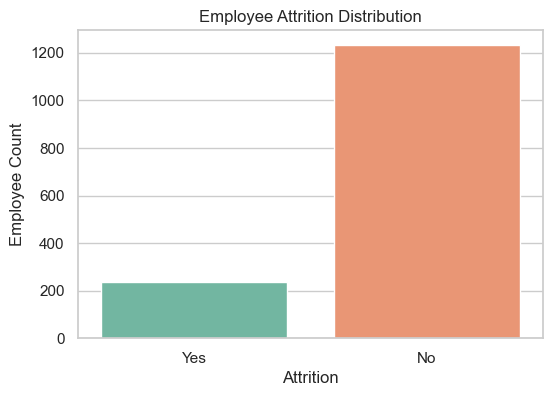

In [9]:
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x="Attrition")
plt.title("Employee Attrition Distribution")
plt.xlabel("Attrition")
plt.ylabel("Employee Count")
plt.savefig(IMAGES_PATH / "target_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

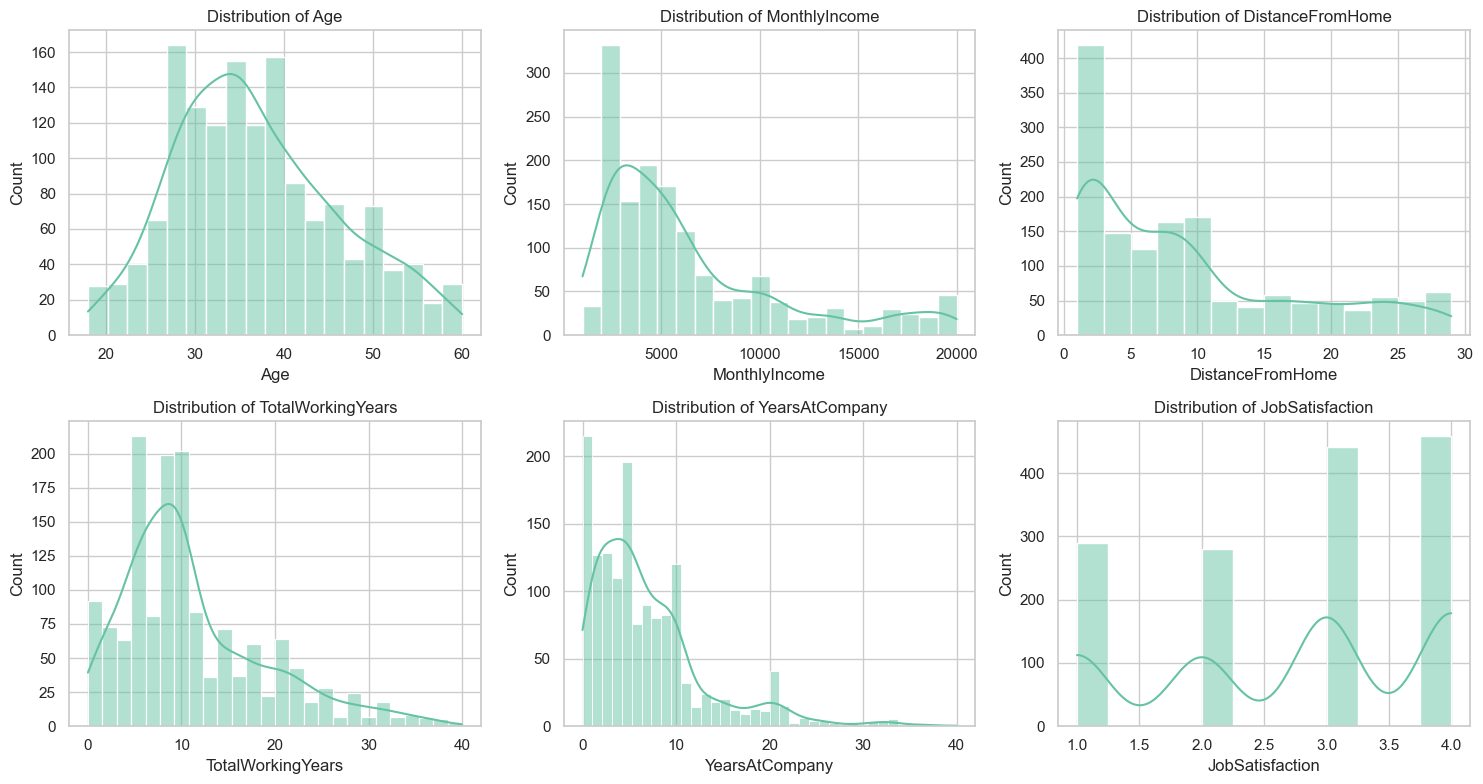

In [10]:
numerical_columns_for_eda = [
    "Age",
    "MonthlyIncome",
    "DistanceFromHome",
    "TotalWorkingYears",
    "YearsAtCompany",
    "JobSatisfaction"
]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for ax, column in zip(axes, numerical_columns_for_eda):
    sns.histplot(data=df, x=column, kde=True, ax=ax)
    ax.set_title(f"Distribution of {column}")

plt.tight_layout()
plt.savefig(IMAGES_PATH / "numerical_feature_distributions.png", dpi=300, bbox_inches="tight")
plt.show()

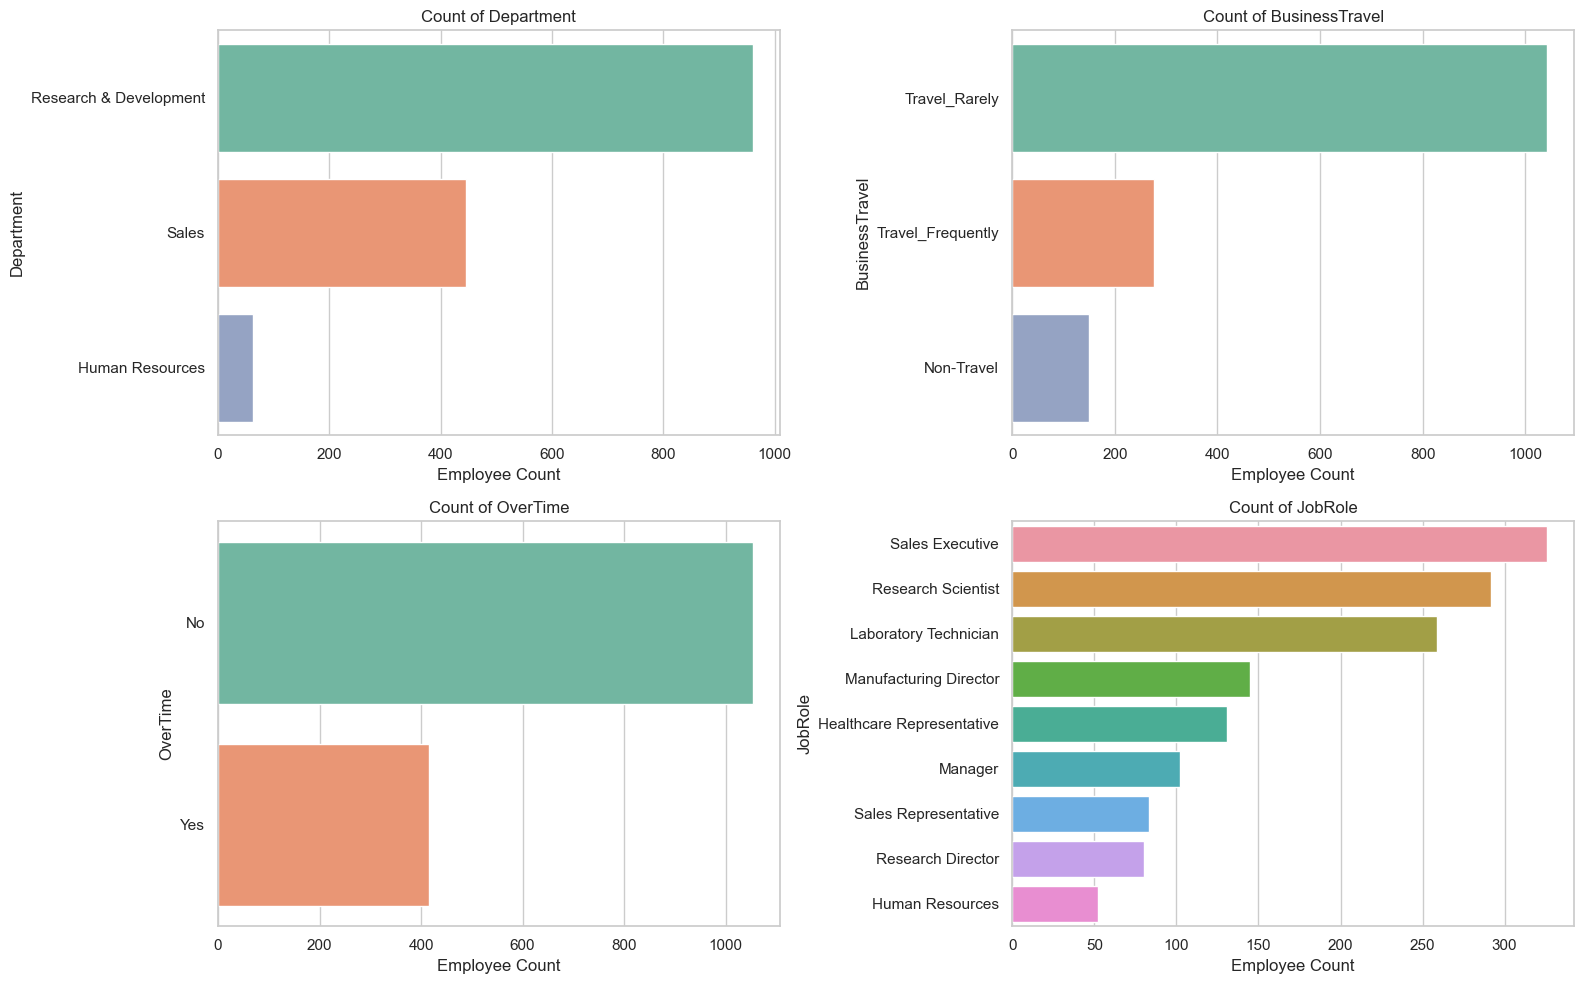

In [11]:
categorical_columns_for_eda = [
    "Department",
    "BusinessTravel",
    "OverTime",
    "JobRole"
]

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()

for ax, column in zip(axes, categorical_columns_for_eda):
    order = df[column].value_counts().index
    sns.countplot(data=df, y=column, order=order, ax=ax)
    ax.set_title(f"Count of {column}")
    ax.set_xlabel("Employee Count")
    ax.set_ylabel(column)

plt.tight_layout()
plt.savefig(IMAGES_PATH / "categorical_feature_counts.png", dpi=300, bbox_inches="tight")
plt.show()

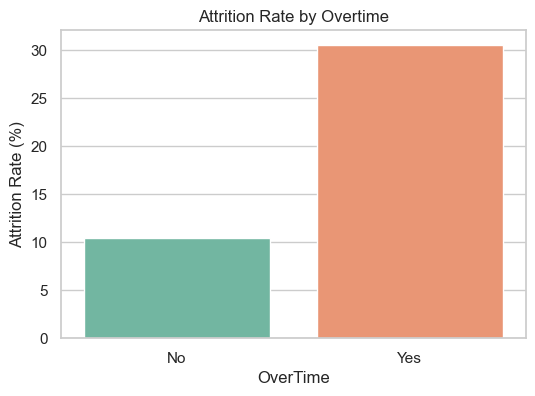

,OverTime,Attrition Rate
0,No,10.436433
1,Yes,30.528846


In [12]:
attrition_rate_by_overtime = (
    df.groupby("OverTime")["Attrition"]
    .apply(lambda x: (x == "Yes").mean() * 100)
    .reset_index(name="Attrition Rate")
)

plt.figure(figsize=(6, 4))
sns.barplot(data=attrition_rate_by_overtime, x="OverTime", y="Attrition Rate")
plt.title("Attrition Rate by Overtime")
plt.ylabel("Attrition Rate (%)")
plt.savefig(IMAGES_PATH / "overtime_vs_attrition.png", dpi=300, bbox_inches="tight")
plt.show()

attrition_rate_by_overtime

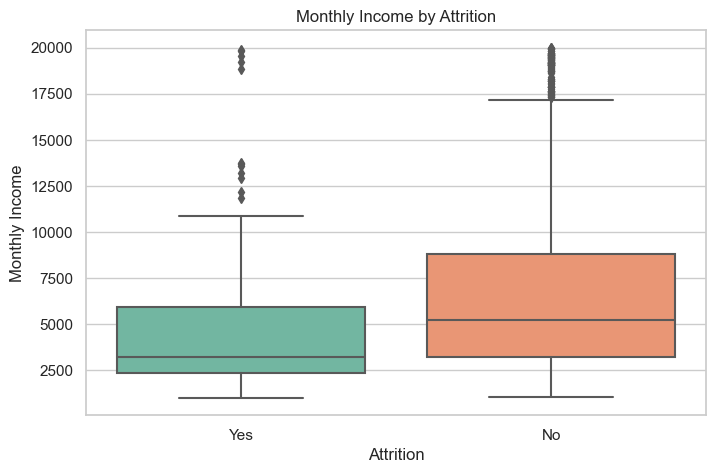

In [13]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x="Attrition", y="MonthlyIncome")
plt.title("Monthly Income by Attrition")
plt.xlabel("Attrition")
plt.ylabel("Monthly Income")
plt.savefig(IMAGES_PATH / "monthly_income_vs_attrition.png", dpi=300, bbox_inches="tight")
plt.show()

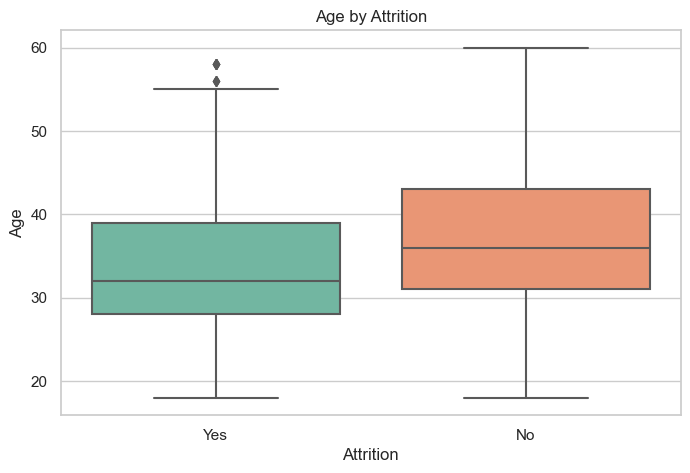

In [14]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x="Attrition", y="Age")
plt.title("Age by Attrition")
plt.xlabel("Attrition")
plt.ylabel("Age")
plt.savefig(IMAGES_PATH / "age_vs_attrition.png", dpi=300, bbox_inches="tight")
plt.show()

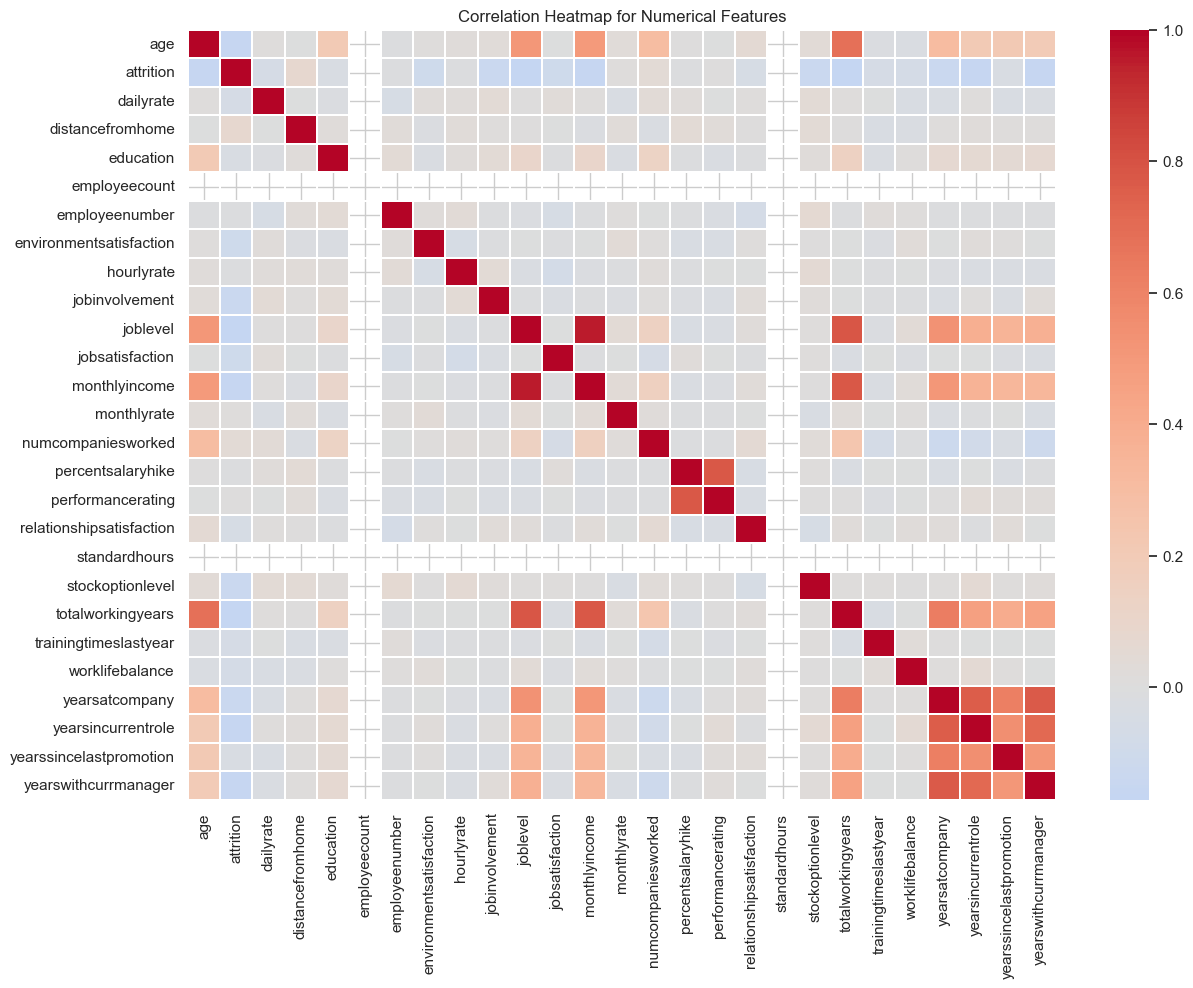

In [15]:
df_corr = clean_column_names(df)
df_corr = encode_binary_target(df_corr, target_column="attrition")

numeric_corr = df_corr.select_dtypes(include=["int64", "float64"]).corr()

plt.figure(figsize=(14, 10))
sns.heatmap(numeric_corr, cmap="coolwarm", center=0, linewidths=0.2)
plt.title("Correlation Heatmap for Numerical Features")
plt.savefig(IMAGES_PATH / "correlation_heatmap.png", dpi=300, bbox_inches="tight")
plt.show()

A few early signals are visible:

- employees working overtime tend to have a higher attrition rate
- income and age show visible differences between employees who stayed and left
- some numerical features are correlated because work history variables often move together

EDA does not prove causality. It gives us useful clues before modeling.

## 8. Data Cleaning

Now we prepare the data for modeling.

Cleaning steps:

- standardize column names
- remove duplicate rows
- encode the target variable (`Yes` = 1, `No` = 0)
- remove constant columns that do not help the model

In [16]:
df_clean = clean_column_names(df)
df_clean = remove_duplicate_rows(df_clean)
df_clean = encode_binary_target(df_clean, target_column="attrition")
df_clean = drop_constant_columns(df_clean)

print("Cleaned dataset shape:", df_clean.shape)
df_clean.head()

Cleaned dataset shape: (1470, 32)


,age,attrition,businesstravel,dailyrate,department,distancefromhome,education,educationfield,employeenumber,environmentsatisfaction,gender,hourlyrate,jobinvolvement,joblevel,jobrole,jobsatisfaction,maritalstatus,monthlyincome,monthlyrate,numcompaniesworked,overtime,percentsalaryhike,performancerating,relationshipsatisfaction,stockoptionlevel,totalworkingyears,trainingtimeslastyear,worklifebalance,yearsatcompany,yearsincurrentrole,yearssincelastpromotion,yearswithcurrmanager
0,41,1,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,2,Female,94,3,2,Sales Executive,4,Single,5993,19479,8,Yes,11,3,1,0,8,0,1,6,4,0,5
1,49,0,Travel_Frequently,279,Research & Development,8,1,Life Sciences,2,3,Male,61,2,2,Research Scientist,2,Married,5130,24907,1,No,23,4,4,1,10,3,3,10,7,1,7
2,37,1,Travel_Rarely,1373,Research & Development,2,2,Other,4,4,Male,92,2,1,Laboratory Technician,3,Single,2090,2396,6,Yes,15,3,2,0,7,3,3,0,0,0,0
3,33,0,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,5,4,Female,56,3,1,Research Scientist,3,Married,2909,23159,1,Yes,11,3,3,0,8,3,3,8,7,3,0
4,27,0,Travel_Rarely,591,Research & Development,2,1,Medical,7,1,Male,40,3,1,Laboratory Technician,2,Married,3468,16632,9,No,12,3,4,1,6,3,3,2,2,2,2


In [17]:
check_missing_values(df_clean).head(10)

,missing_count,missing_percentage
age,0,0.0
attrition,0,0.0
yearssincelastpromotion,0,0.0
yearsincurrentrole,0,0.0
yearsatcompany,0,0.0
worklifebalance,0,0.0
trainingtimeslastyear,0,0.0
totalworkingyears,0,0.0
stockoptionlevel,0,0.0
relationshipsatisfaction,0,0.0


## 9. Feature Engineering

Logistic Regression needs numeric input. That means:

- categorical variables should be encoded
- numerical variables should be scaled

Scaling is important because Logistic Regression uses coefficients. Without scaling, large-unit features can dominate the optimization process.

We also create a few simple HR features that are easy to explain:

- `income_per_job_level`
- `years_without_promotion_ratio`
- `early_career_flag`
- `long_commute_flag`

In [18]:
df_model = create_employee_features(df_clean)
df_model = drop_identifier_columns(df_model)

PROCESSED_PATH.parent.mkdir(exist_ok=True)
df_model.to_csv(PROCESSED_PATH, index=False)

print("Modeling dataset shape:", df_model.shape)
df_model.head()

Modeling dataset shape: (1470, 35)


,age,attrition,businesstravel,dailyrate,department,distancefromhome,education,educationfield,environmentsatisfaction,gender,hourlyrate,jobinvolvement,joblevel,jobrole,jobsatisfaction,maritalstatus,monthlyincome,monthlyrate,numcompaniesworked,overtime,percentsalaryhike,performancerating,relationshipsatisfaction,stockoptionlevel,totalworkingyears,trainingtimeslastyear,worklifebalance,yearsatcompany,yearsincurrentrole,yearssincelastpromotion,yearswithcurrmanager,income_per_job_level,years_without_promotion_ratio,early_career_flag,long_commute_flag
0,41,1,Travel_Rarely,1102,Sales,1,2,Life Sciences,2,Female,94,3,2,Sales Executive,4,Single,5993,19479,8,Yes,11,3,1,0,8,0,1,6,4,0,5,2996.5,0.000,0,0
1,49,0,Travel_Frequently,279,Research & Development,8,1,Life Sciences,3,Male,61,2,2,Research Scientist,2,Married,5130,24907,1,No,23,4,4,1,10,3,3,10,7,1,7,2565.0,0.100,0,0
2,37,1,Travel_Rarely,1373,Research & Development,2,2,Other,4,Male,92,2,1,Laboratory Technician,3,Single,2090,2396,6,Yes,15,3,2,0,7,3,3,0,0,0,0,2090.0,0.000,0,0
3,33,0,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,4,Female,56,3,1,Research Scientist,3,Married,2909,23159,1,Yes,11,3,3,0,8,3,3,8,7,3,0,2909.0,0.375,0,0
4,27,0,Travel_Rarely,591,Research & Development,2,1,Medical,1,Male,40,3,1,Laboratory Technician,2,Married,3468,16632,9,No,12,3,4,1,6,3,3,2,2,2,2,3468.0,1.000,0,0


In [19]:
numerical_features, categorical_features = get_feature_types(
    df_model,
    target_column="attrition"
)

print("Numerical features:", len(numerical_features))
print(numerical_features)
print()
print("Categorical features:", len(categorical_features))
print(categorical_features)

Numerical features: 27
['age', 'dailyrate', 'distancefromhome', 'education', 'environmentsatisfaction', 'hourlyrate', 'jobinvolvement', 'joblevel', 'jobsatisfaction', 'monthlyincome', 'monthlyrate', 'numcompaniesworked', 'percentsalaryhike', 'performancerating', 'relationshipsatisfaction', 'stockoptionlevel', 'totalworkingyears', 'trainingtimeslastyear', 'worklifebalance', 'yearsatcompany', 'yearsincurrentrole', 'yearssincelastpromotion', 'yearswithcurrmanager', 'income_per_job_level', 'years_without_promotion_ratio', 'early_career_flag', 'long_commute_flag']

Categorical features: 7
['businesstravel', 'department', 'educationfield', 'gender', 'jobrole', 'maritalstatus', 'overtime']


## 10. Train-Test Split

We split the data into training and testing sets.

The model learns from the training data. We evaluate it on the test data to check how it performs on employees it has not seen before.

Because the target is imbalanced, we use a stratified split so both train and test sets keep a similar attrition ratio.

In [20]:
X, y = split_features_target(df_model, target_column="attrition")

X_train, X_test, y_train, y_test = perform_train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=True
)

print_dataset_shapes(X_train, X_test, y_train, y_test)

Training Features Shape: (1176, 34)
Testing Features Shape: (294, 34)
Training Target Shape: (1176,)
Testing Target Shape: (294,)


## 11. Build Baseline Logistic Regression Model

This is our main model. We keep it intentionally simple because the purpose of this project is to understand Logistic Regression deeply.

The pipeline does two jobs:

1. preprocess features
2. train Logistic Regression

In [21]:
preprocessor = build_preprocessor(
    numerical_features,
    categorical_features
)

logistic_model = initialize_logistic_regression(
    class_weight=None,
    random_state=42
)

model_pipeline = build_model_pipeline(
    preprocessor,
    logistic_model
)

model_pipeline = train_logistic_regression_model(
    model_pipeline,
    X_train,
    y_train
)

model_pipeline

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['age', 'dailyrate',
                                                   'distancefromhome',
                                                   'education',
                                                   'environmentsatisfaction',
                                                   'hourlyrate',
                                                   'jobinvolvement', 'joblevel',
                                                   'jobsatisfaction',
                                                   'monthlyincome',
                                                   'monthlyrate',
                                                   'numcompaniesworked',
                                                   'percentsalaryhike',
                                                   'performancerating',
                                                   'relationshipsatisfaction',
                                                   'stockopt...
                                                   'yearssincelastpromotion',
                                                   'yearswithcurrmanager',
                                                   'income_per_job_level',
                                                   'years_without_promotion_ratio',
                                                   'early_career_flag',
                                                   'long_commute_flag']),
                                                 ('cat',
                                                  OneHotEncoder(drop='first',
                                                                handle_unknown='ignore'),
                                                  ['businesstravel',
                                                   'department',
                                                   'educationfield', 'gender',
                                                   'jobrole', 'maritalstatus',
                                                   'overtime'])])),
                ('model', LogisticRegression(max_iter=1000, random_state=42))])

## 12. Model Evaluation

For classification, we need more than one metric.

We will evaluate:

- accuracy
- precision
- recall
- F1-score
- confusion matrix
- ROC-AUC
- classification report

In [22]:
y_pred = generate_predictions(
    model_pipeline,
    X_test,
    threshold=0.5
)

y_prob = generate_prediction_probabilities(
    model_pipeline,
    X_test
)

metrics = evaluate_classification_model(
    y_test,
    y_pred,
    y_prob
)

print_metrics(metrics)

Model Evaluation Metrics
------------------------------
Accuracy: 0.8639
Precision: 0.6667
Recall: 0.2979
F1: 0.4118
ROC_AUC: 0.8107


In [23]:
get_classification_report(y_test, y_pred)

,precision,recall,f1-score,support
0,0.879121,0.971660,0.923077,247.000000
1,0.666667,0.297872,0.411765,47.000000
accuracy,0.863946,0.863946,0.863946,0.863946
macro avg,0.772894,0.634766,0.667421,294.000000
weighted avg,0.845157,0.863946,0.841337,294.000000


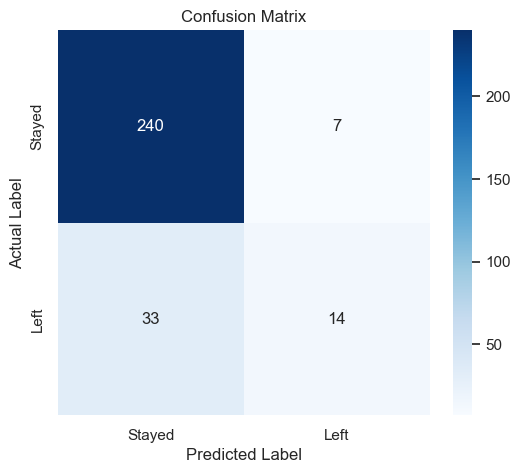

In [24]:
plot_confusion_matrix(
    y_test,
    y_pred,
    labels=["Stayed", "Left"],
    save_path=IMAGES_PATH / "confusion_matrix.png"
)

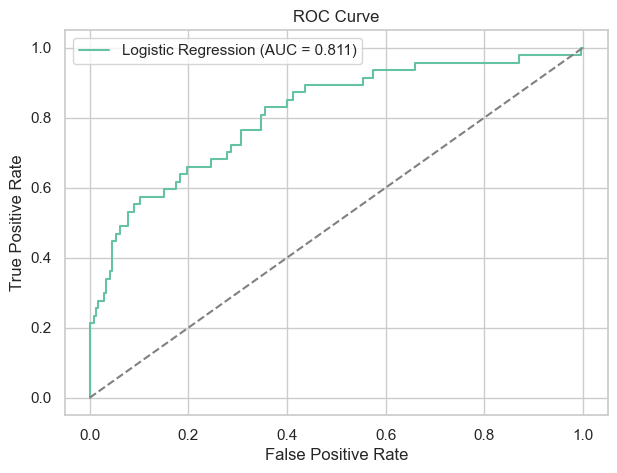

In [25]:
plot_roc_curve(
    y_test,
    y_prob,
    save_path=IMAGES_PATH / "roc_curve.png"
)

## 13. Understanding Confusion Matrix

A confusion matrix shows where the model is right and wrong.

For this project:

- **True Negative (TN):** employee stayed, model predicted stayed
- **True Positive (TP):** employee left, model predicted left
- **False Positive (FP):** employee stayed, model predicted left
- **False Negative (FN):** employee left, model predicted stayed

In attrition prediction, false negatives can be expensive because the company misses employees who may need support.

In [26]:
cm = confusion_matrix(y_test, y_pred)
cm_df = pd.DataFrame(
    cm,
    index=["Actual Stayed", "Actual Left"],
    columns=["Predicted Stayed", "Predicted Left"]
)
cm_df

,Predicted Stayed,Predicted Left
Actual Stayed,240,7
Actual Left,33,14


## 14. Precision vs Recall

Precision and recall answer different business questions.

**Precision** asks:

> When the model predicts an employee will leave, how often is it correct?

**Recall** asks:

> Of all employees who actually left, how many did the model catch?

For employee attrition, recall is often very important. Missing a true at-risk employee means the company may lose the chance to intervene.

But precision still matters. If precision is too low, HR teams may spend time investigating too many employees who were not actually likely to leave.

## 15. ROC Curve and AUC

The ROC curve compares the true positive rate and false positive rate across many thresholds.

ROC-AUC summarizes that curve into one number.

AUC intuition:

- 0.50 means the model is close to random guessing
- 0.70 to 0.80 means useful signal
- 0.80+ means strong separation

AUC is helpful because it evaluates probability ranking, not just one fixed threshold.

In [27]:
print(f"ROC-AUC Score: {metrics['ROC_AUC']:.4f}")

ROC-AUC Score: 0.8107


## 16. Coefficient Interpretation

Logistic Regression is popular because it is interpretable.

Each coefficient tells us how a feature changes the log-odds of the positive class, which here means attrition.

Simple intuition:

- positive coefficient: pushes prediction toward attrition
- negative coefficient: pushes prediction toward staying
- larger absolute coefficient: stronger influence, after preprocessing

The odds ratio is `exp(coefficient)`:

- odds ratio above 1 increases attrition odds
- odds ratio below 1 decreases attrition odds

In [28]:
fitted_preprocessor = model_pipeline.named_steps["preprocessor"]
feature_names = get_processed_feature_names(
    fitted_preprocessor,
    numerical_features,
    categorical_features
)

coefficients_df = get_coefficients(
    model_pipeline,
    feature_names
)

coefficients_df.head(15)

,Feature,Coefficient,Odds_Ratio,Absolute_Coefficient
47,overtime_Yes,1.820532,6.175144,1.820532
27,businesstravel_Travel_Frequently,1.579116,4.850665,1.579116
38,jobrole_Laboratory Technician,1.209497,3.351798,1.209497
41,jobrole_Research Director,-0.972336,0.378199,0.972336
34,educationfield_Other,-0.793686,0.452175,0.793686
46,maritalstatus_Single,0.725330,2.065413,0.725330
28,businesstravel_Travel_Rarely,0.701829,2.017439,0.701829
21,yearssincelastpromotion,0.677078,1.968119,0.677078
44,jobrole_Sales Representative,0.612610,1.845242,0.612610
11,numcompaniesworked,0.559265,1.749386,0.559265


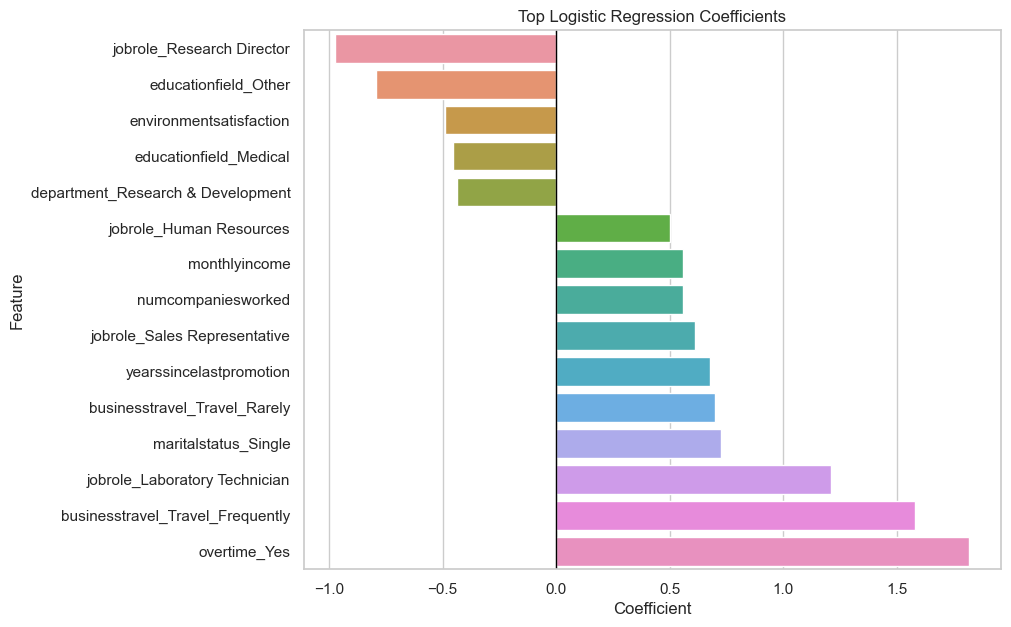

In [29]:
plot_top_coefficients(
    coefficients_df,
    top_n=15,
    save_path=IMAGES_PATH / "top_logistic_coefficients.png"
)

## 17. Threshold Tuning

The default threshold is 0.5.

That means:

> predict attrition if probability is at least 50%

But business problems do not always want the default threshold.

If we lower the threshold, the model catches more possible attrition cases, usually increasing recall. The tradeoff is that precision may drop.

In [30]:
threshold_results = threshold_summary(
    y_test,
    y_prob,
    thresholds=[0.2, 0.3, 0.4, 0.5, 0.6, 0.7]
)

threshold_results

,Threshold,Accuracy,Precision,Recall,F1
0,0.2,0.789116,0.397260,0.617021,0.483333
1,0.3,0.853741,0.543478,0.531915,0.537634
2,0.4,0.867347,0.617647,0.446809,0.518519
3,0.5,0.863946,0.666667,0.297872,0.411765
4,0.6,0.867347,0.750000,0.255319,0.380952
5,0.7,0.870748,1.000000,0.191489,0.321429


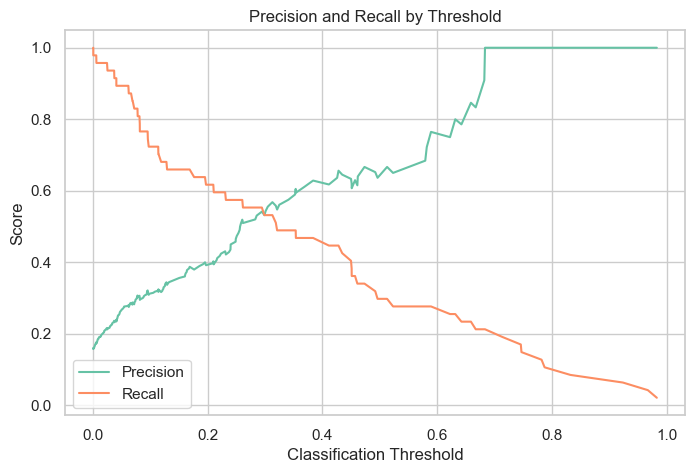

In [31]:
plot_precision_recall_by_threshold(
    y_test,
    y_prob,
    save_path=IMAGES_PATH / "precision_recall_threshold.png"
)

In an HR setting, a lower threshold may be reasonable if the company wants to catch more at-risk employees early.

The best threshold depends on the cost of each mistake:

- false negative: missed employee who leaves
- false positive: employee flagged as risky but does not leave

## 18. Final Model Summary

The Logistic Regression model gives us a clean baseline for employee attrition prediction.

What it does well:

- produces probabilities, not just labels
- gives interpretable coefficients
- supports threshold tuning
- works well as a first model for binary classification

What to watch:

- attrition is imbalanced, so accuracy alone is not enough
- coefficients show association, not causation
- some employee behavior may be hard to capture with structured HR data alone

In [32]:
summary_table = pd.DataFrame([metrics]).T
summary_table.columns = ["Score"]
summary_table

,Score
Accuracy,0.863946
Precision,0.666667
Recall,0.297872
F1,0.411765
ROC_AUC,0.810664


## 19. Key Learnings

Here are the biggest takeaways from this project:

1. Logistic Regression predicts probabilities for binary outcomes.
2. A threshold converts probabilities into class predictions.
3. Accuracy can be misleading when classes are imbalanced.
4. Precision and recall help explain different types of mistakes.
5. ROC-AUC measures how well the model separates classes across thresholds.
6. Coefficients make Logistic Regression easier to explain to business stakeholders.
7. Threshold tuning connects model behavior to business priorities.

## 20. Interview Questions

Here are interview-style questions you should be ready to answer after this project:

1. What is Logistic Regression?
2. Why is it called regression if it is used for classification?
3. What does the sigmoid function do?
4. What are log-odds?
5. What is a probability threshold?
6. What is a confusion matrix?
7. How are accuracy, precision, recall, and F1-score different?
8. When is recall more important than precision?
9. When is precision more important than recall?
10. What is ROC-AUC?
11. What is class imbalance?
12. How can class imbalance affect model evaluation?
13. What assumptions does Logistic Regression make?
14. How is Logistic Regression different from Linear Regression?
15. How would you explain this attrition model to an HR leader?

The full answers are available in `interview_questions.md`.